In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

--- Image Counts per Class ---
Split                 test  train  val
Class                                 
cataract                55   1300   54
diabetic_retinopathy   152   1300  150
glaucoma               136   1300  134
normal                 103   1300  102


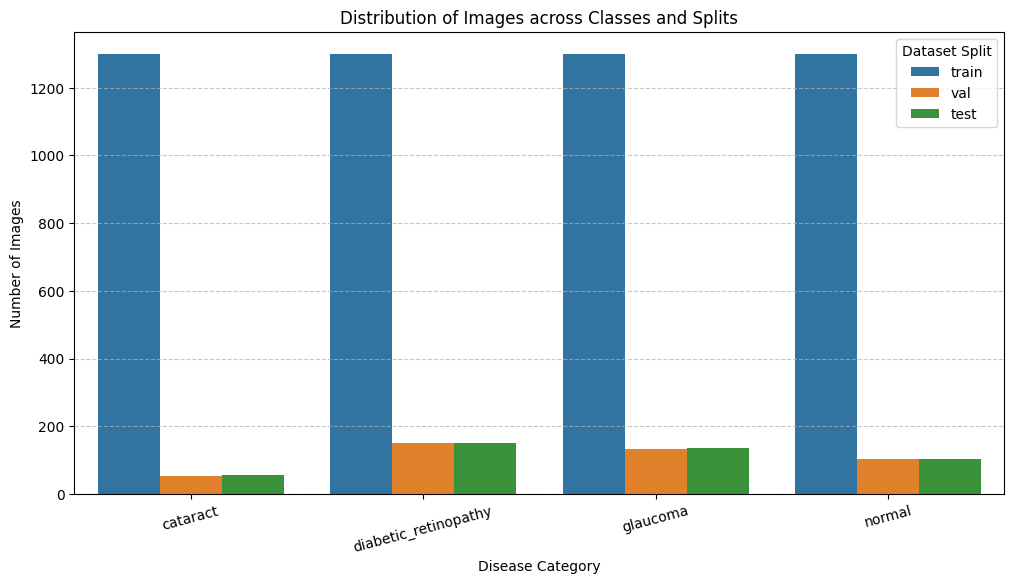

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the path to your dataset
base_path = '/kaggle/input/datasets/mahin661/eye-disease-classification-fundus-image-dataset/dataset2_balanced'  # Adjust if your path is different
splits = ['train', 'val', 'test']
classes = ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']

# Collect data counts
data_counts = []
for split in splits:
    for cls in classes:
        folder_path = os.path.join(base_path, split, cls)
        if os.path.exists(folder_path):
            count = len(os.listdir(folder_path))
            data_counts.append({'Split': split, 'Class': cls, 'Count': count})

# Create a DataFrame
df_counts = pd.DataFrame(data_counts)

# Pivot for a better view
pivot_df = df_counts.pivot(index='Class', columns='Split', values='Count').fillna(0).astype(int)
print("--- Image Counts per Class ---")
print(pivot_df)

# Plotting the distribution
plt.figure(figsize=(12, 6))
sns.barplot(data=df_counts, x='Class', y='Count', hue='Split')
plt.title('Distribution of Images across Classes and Splits')
plt.ylabel('Number of Images')
plt.xlabel('Disease Category')
plt.xticks(rotation=15)
plt.legend(title='Dataset Split')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

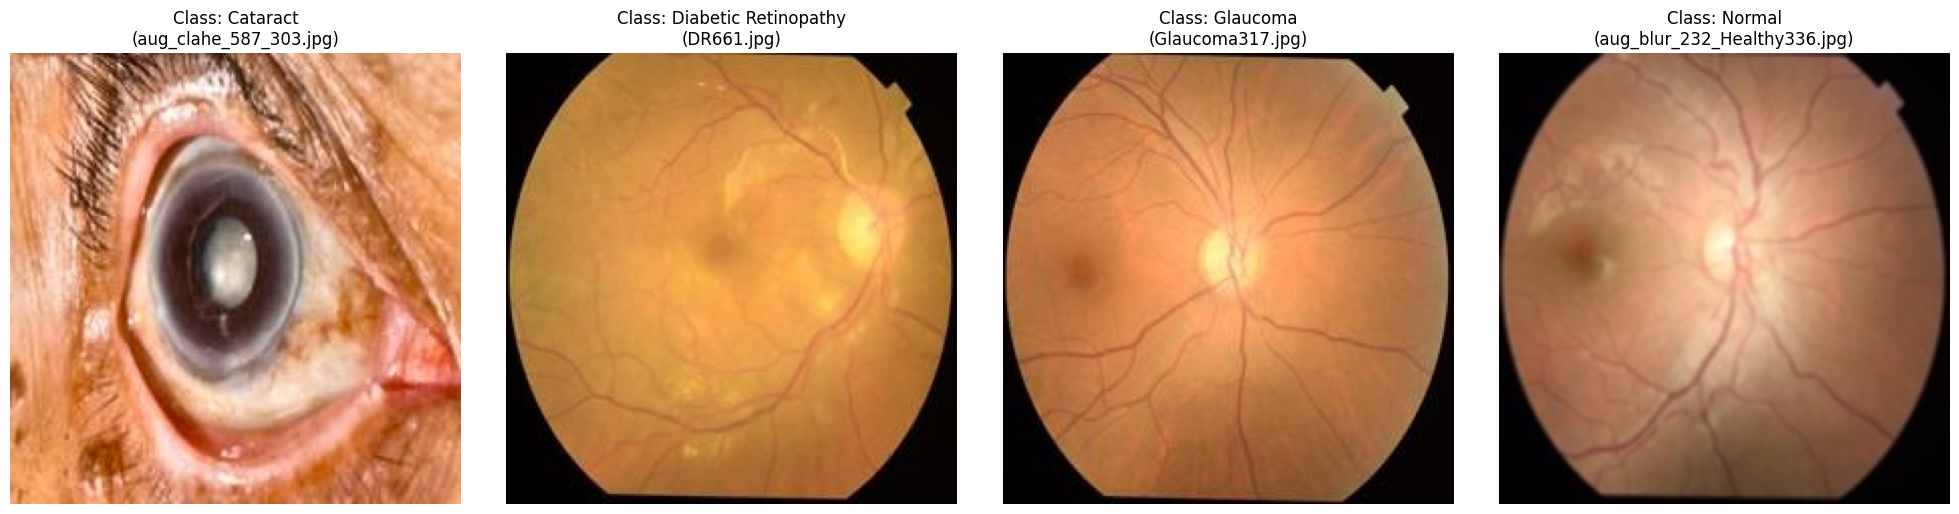

In [2]:
import matplotlib.image as mpimg
import random

def plot_samples(base_path, classes, split='train'):
    plt.figure(figsize=(20, 5))
    
    for i, cls in enumerate(classes):
        folder_path = os.path.join(base_path, split, cls)
        # Get a list of all images in the folder
        images = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        if images:
            # Pick one random image
            img_name = random.choice(images)
            img_path = os.path.join(folder_path, img_name)
            
            # Load and plot
            img = mpimg.imread(img_path)
            plt.subplot(1, 4, i + 1)
            plt.imshow(img)
            plt.title(f"Class: {cls.replace('_', ' ').title()}\n({img_name})")
            plt.axis('off')
        else:
            print(f"No images found in {folder_path}")
            
    plt.tight_layout()
    plt.show()

# Run the visualization
plot_samples(base_path, classes)

In [7]:
import torch
import os
import timm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_PATH = "/kaggle/input/datasets/mahin661/eye-disease-classification-fundus-image-dataset/dataset2_balanced"

print(f"Device: {DEVICE}")
print(f"Data Path: {DATA_PATH}")

Device: cuda
Data Path: /kaggle/input/datasets/mahin661/eye-disease-classification-fundus-image-dataset/dataset2_balanced


In [8]:
import torch.nn as nn

class AttentionHead(nn.Module):
    def __init__(self, in_features, num_classes):
        super(AttentionHead, self).__init__()
        self.attention = nn.Sequential(
            nn.Linear(in_features, in_features // 16),
            nn.ReLU(inplace=True),
            nn.Linear(in_features // 16, in_features),
            nn.Sigmoid()
        )
        self.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        weights = self.attention(x)
        x = x * weights  
        return self.fc(x)

print("Architecture Defined.")

Architecture Defined.


In [9]:
import cv2
import numpy as np
from PIL import Image
from torchvision import transforms, datasets
from torch.utils.data import Dataset

def apply_clahe(img):
    img_np = np.array(img)
    lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    lab[...,0] = clahe.apply(lab[...,0])
    return Image.fromarray(cv2.cvtColor(lab, cv2.COLOR_LAB2RGB))

IMG_SIZE = 384 

train_transforms = transforms.Compose([
    transforms.Lambda(apply_clahe),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Lambda(apply_clahe),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class MapDataset(Dataset):
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform
    def __getitem__(self, index):
        image, label = self.dataset[index]
        if self.transform: image = self.transform(image)
        return image, label
    def __len__(self): return len(self.dataset)

print("Preprocessing Pipeline Ready.")

Preprocessing Pipeline Ready.


In [10]:
from sklearn.model_selection import KFold
from torch.utils.data import ConcatDataset

raw_train = datasets.ImageFolder(os.path.join(DATA_PATH, 'train'))
raw_val = datasets.ImageFolder(os.path.join(DATA_PATH, 'val'))
dev_pool = ConcatDataset([raw_train, raw_val])

K_FOLDS = 5
kf = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

print(f"Dataset Merged: {len(dev_pool)} total images for 5-fold CV.")

Dataset Merged: 5640 total images for 5-fold CV.


In [12]:
from torch.utils.data import Subset, DataLoader
from tqdm import tqdm

EPOCHS = 20
BATCH_SIZE = 32 
best_val_loss = float('inf')
SAVE_PATH = "best_enhanced_model.pth"

# Dictionary to store performance across folds
fold_histories = []

# Class weights
weights = torch.tensor([1.0, 1.0, 1.3, 1.3]).to(DEVICE)

for fold, (train_idx, val_idx) in enumerate(kf.split(dev_pool)):
    print(f"\n--- FOLD {fold+1} ---")
    
    train_loader = DataLoader(MapDataset(Subset(dev_pool, train_idx), train_transforms), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(MapDataset(Subset(dev_pool, val_idx), val_transforms), batch_size=BATCH_SIZE)

    model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=0)
    model.classifier = AttentionHead(model.num_features, 4)
    model.to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss(weight=weights)
    
    history = {'train': [], 'val': []}

    for epoch in range(EPOCHS):
        # TRAIN
        model.train()
        t_loss = 0
        for imgs, lbls in tqdm(train_loader, desc=f"Ep {epoch+1}"):
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs), lbls)
            loss.backward()
            optimizer.step()
            t_loss += loss.item()
        
        # VAL
        model.eval()
        v_loss = 0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
                v_loss += criterion(model(imgs), lbls).item()
        
        train_avg = t_loss / len(train_loader)
        val_avg = v_loss / len(val_loader)
        
        history['train'].append(train_avg)
        history['val'].append(val_avg)
        
        print(f"Epoch {epoch+1} | Train Loss: {train_avg:.4f} | Val Loss: {val_avg:.4f}")

        if val_avg < best_val_loss:
            best_val_loss = val_avg
            torch.save(model.state_dict(), SAVE_PATH)
            print(f"⭐ Saved Best Model")
            
    fold_histories.append(history)


--- FOLD 1 ---


Ep 1: 100%|██████████| 141/141 [02:13<00:00,  1.05it/s]


Epoch 1 | Train Loss: 0.6352 | Val Loss: 0.3017
⭐ Saved Best Model


Ep 2: 100%|██████████| 141/141 [01:54<00:00,  1.23it/s]


Epoch 2 | Train Loss: 0.3197 | Val Loss: 0.2535
⭐ Saved Best Model


...

Epoch 18 | Train Loss: 0.1056 | Val Loss: 0.3775


Ep 19: 100%|██████████| 141/141 [01:53<00:00,  1.24it/s]


Epoch 19 | Train Loss: 0.1010 | Val Loss: 0.3663


Ep 20: 100%|██████████| 141/141 [01:54<00:00,  1.23it/s]


Epoch 20 | Train Loss: 0.1033 | Val Loss: 0.3464


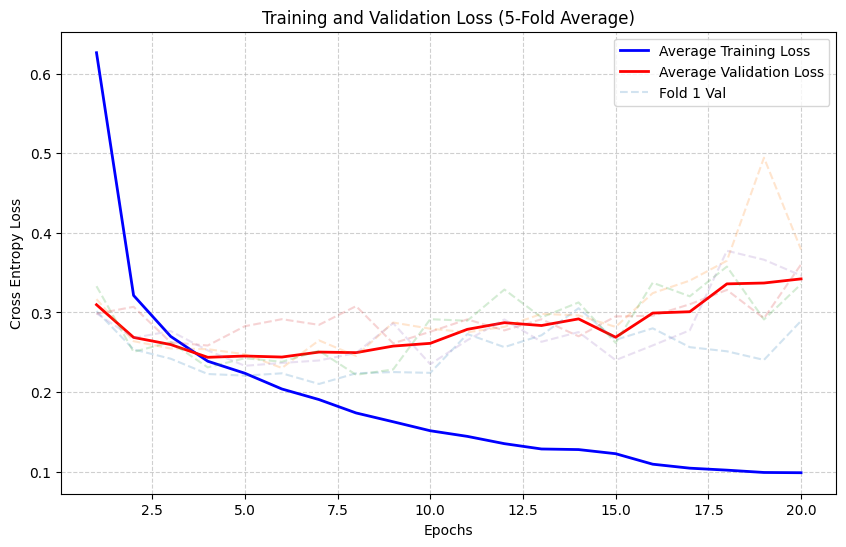

In [13]:
import matplotlib.pyplot as plt
import numpy as np

def plot_learning_curves(fold_histories):
    plt.figure(figsize=(10, 6))
    
    # Calculate average losses across all folds
    avg_train_loss = np.mean([h['train'] for h in fold_histories], axis=0)
    avg_val_loss = np.mean([h['val'] for h in fold_histories], axis=0)
    
    epochs_range = range(1, len(avg_train_loss) + 1)

    plt.plot(epochs_range, avg_train_loss, 'b-', label='Average Training Loss', linewidth=2)
    plt.plot(epochs_range, avg_val_loss, 'r-', label='Average Validation Loss', linewidth=2)
    
    # Optional: Plot the individual fold val losses with lower opacity
    for i, h in enumerate(fold_histories):
        plt.plot(epochs_range, h['val'], alpha=0.2, linestyle='--', label=f'Fold {i+1} Val' if i==0 else "")

    plt.title('Training and Validation Loss (5-Fold Average)')
    plt.xlabel('Epochs')
    plt.ylabel('Cross Entropy Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Run the plot
plot_learning_curves(fold_histories)

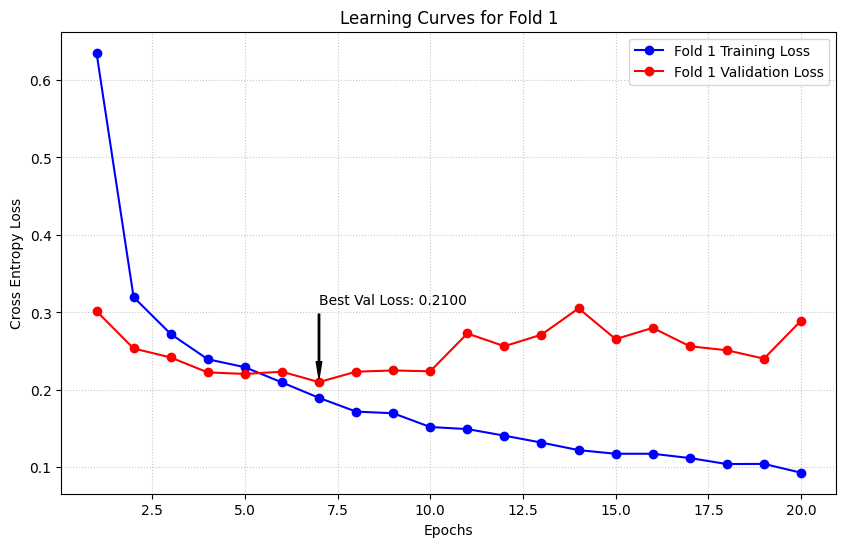

In [15]:
def plot_single_fold(fold_histories, fold_num=1):
    # Adjust for 0-based indexing
    idx = fold_num - 1
    
    if idx >= len(fold_histories):
        print(f"Error: Fold {fold_num} data not found. You only have {len(fold_histories)} folds.")
        return

    fold_data = fold_histories[idx]
    epochs_range = range(1, len(fold_data['train']) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(epochs_range, fold_data['train'], 'b-o', label=f'Fold {fold_num} Training Loss')
    plt.plot(epochs_range, fold_data['val'], 'r-o', label=f'Fold {fold_num} Validation Loss')

    plt.title(f'Learning Curves for Fold {fold_num}')
    plt.xlabel('Epochs')
    plt.ylabel('Cross Entropy Loss')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    
    # Annotate the best (lowest) val loss point
    min_val_loss = min(fold_data['val'])
    min_idx = fold_data['val'].index(min_val_loss) + 1
    plt.annotate(f'Best Val Loss: {min_val_loss:.4f}', 
                 xy=(min_idx, min_val_loss), 
                 xytext=(min_idx, min_val_loss + 0.1),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=4))

    plt.show()

# Run the plot for Fold 1
plot_single_fold(fold_histories, fold_num=1)

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


test_model = timm.create_model('efficientnet_b0', num_classes=0)
test_model.classifier = AttentionHead(test_model.num_features, 4)
test_model.load_state_dict(torch.load(SAVE_PATH))
test_model.to(DEVICE).eval()


test_ds = datasets.ImageFolder(os.path.join(DATA_PATH, 'test'), transform=val_transforms)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

y_true, y_pred = [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        out = test_model(imgs.to(DEVICE))
        y_pred.extend(torch.argmax(out, dim=1).cpu().numpy())
        y_true.extend(lbls.numpy())

print(classification_report(y_true, y_pred, target_names=test_ds.classes))

                      precision    recall  f1-score   support

            cataract       1.00      1.00      1.00        55
diabetic_retinopathy       0.99      0.96      0.98       152
            glaucoma       0.81      0.83      0.82       136
              normal       0.75      0.77      0.76       103

            accuracy                           0.88       446
           macro avg       0.89      0.89      0.89       446
        weighted avg       0.88      0.88      0.88       446



In [4]:
import os
from torchvision import datasets
from torch.utils.data import ConcatDataset

# Define paths
DATA_PATH = "/kaggle/input/datasets/mahin661/eye-disease-classification-fundus-image-dataset/dataset2_balanced"
train_dir = os.path.join(DATA_PATH, 'train')
val_dir = os.path.join(DATA_PATH, 'val')
test_dir = os.path.join(DATA_PATH, 'test')

# 1. Load the individual datasets
train_ds_raw = datasets.ImageFolder(train_dir)
val_ds_raw = datasets.ImageFolder(val_dir)
test_ds_raw = datasets.ImageFolder(test_dir)

# 2. Merge Train and Val into the Development Pool
dev_ds_merged = ConcatDataset([train_ds_raw, val_ds_raw])

# 3. Print the Counts
print(f"{'Dataset Split':<20} | {'Total Image Count':<20}")
print("-" * 45)
print(f"{'Original Train':<20} | {len(train_ds_raw):<20}")
print(f"{'Original Val':<20} | {len(val_ds_raw):<20}")
print(f"{'NEW Development Pool':<20} | {len(dev_ds_merged):<20}")
print(f"{'Gold Standard Test':<20} | {len(test_ds_raw):<20}")

# Verify class consistency
print(f"\nDetected Classes: {train_ds_raw.classes}")

Dataset Split        | Total Image Count   
---------------------------------------------
Original Train       | 5200                
Original Val         | 440                 
NEW Development Pool | 5640                
Gold Standard Test   | 446                 

Detected Classes: ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']


In [5]:
from torchvision import transforms
from torch.utils.data import Dataset
import PIL.Image as Image

# 1. Define Training Augmentations (Safe for Fundus Images)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.1, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 2. Define Validation/Test Transforms (No Augmentation)
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 3. Custom Wrapper to apply transforms dynamically during K-Fold
class MapDataset(Dataset):
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform

    def __getitem__(self, index):
        image, label = self.dataset[index]
        if self.transform:
            image = self.transform(image)
        return image, label

    def __len__(self):
        return len(self.dataset)

print("Augmentation pipelines defined.")

Augmentation pipelines defined.


In [7]:
import torch
import torch.nn as nn

class AttentionHead(nn.Module):
    def __init__(self, in_features, num_classes):
        super(AttentionHead, self).__init__()
        # Squeeze-and-Excitation style attention
        self.attention = nn.Sequential(
            nn.Linear(in_features, in_features // 16),
            nn.ReLU(inplace=True),
            nn.Linear(in_features // 16, in_features),
            nn.Sigmoid()
        )
        self.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        # Global Average Pooling output is usually (batch, features)
        # Apply the attention weights
        weights = self.attention(x)
        x = x * weights  
        return self.fc(x)

print("AttentionHead class defined successfully.")

AttentionHead class defined successfully.


In [11]:
import torch
import os

# 1. Define the Device (Crucial for Kaggle GPUs)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# 2. Define your Data Path (Double check this matches your Kaggle input exactly)
DATA_PATH = "/kaggle/input/datasets/mahin661/eye-disease-classification-fundus-image-dataset/dataset2_balanced"

# 3. Quick check to make sure the path is accessible
if os.path.exists(DATA_PATH):
    print("✅ Dataset path found!")
else:
    print("❌ Dataset path NOT found. Please check the Kaggle input sidebar.")

Using device: cuda
✅ Dataset path found!


In [12]:
import torch
import torch.nn as nn
from sklearn.model_selection import KFold
from torch.utils.data import ConcatDataset, DataLoader, Subset
from tqdm import tqdm
import timm

# Setup
K_FOLDS = 5
EPOCHS = 20
best_val_loss = float('inf')
SAVE_PATH = "best_eye_disease_model.pth"

# Merge raw datasets (without transforms yet)
raw_train = datasets.ImageFolder(f"{DATA_PATH}/train")
raw_val = datasets.ImageFolder(f"{DATA_PATH}/val")
dev_pool = ConcatDataset([raw_train, raw_val])

kf = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

# Training Loop
for fold, (train_idx, val_idx) in enumerate(kf.split(dev_pool)):
    print(f"\n{'='*10} FOLD {fold+1}/{K_FOLDS} {'='*10}")
    
    # Create fold-specific subsets with their respective transforms
    train_sub = Subset(dev_pool, train_idx)
    val_sub = Subset(dev_pool, val_idx)
    
    train_loader = DataLoader(MapDataset(train_sub, transform=train_transforms), batch_size=32, shuffle=True)
    val_loader = DataLoader(MapDataset(val_sub, transform=val_transforms), batch_size=32, shuffle=False)
    
    # Initialize Model, Optimizer, and Loss
    model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=0)
    model.classifier = AttentionHead(model.num_features, 4) # Using the AttentionHead class you liked
    model.to(DEVICE)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(EPOCHS):
        # -- TRAIN PHASE --
        model.train()
        running_loss = 0.0
        for images, labels in tqdm(train_loader, desc=f"Fold {fold+1} Epoch {epoch+1}"):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            
        # -- VAL PHASE --
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                v_out = model(images)
                val_loss += criterion(v_out, labels).item()
        
        avg_val_loss = val_loss / len(val_loader)
        print(f"Epoch {epoch+1} Val Loss: {avg_val_loss:.4f}")
        
        # SAVE BEST MODEL
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), SAVE_PATH)
            print(f"⭐ New Best Model Saved (Loss: {best_val_loss:.4f})")

print("\nTraining Complete. Best model weights are secured.")


========== FOLD 1/5 ==========


Fold 1 Epoch 1: 100%|██████████| 141/141 [01:09<00:00,  2.03it/s]


Epoch 1 Val Loss: 0.2828
⭐ New Best Model Saved (Loss: 0.2828)


Fold 1 Epoch 2: 100%|██████████| 141/141 [00:39<00:00,  3.55it/s]


Epoch 2 Val Loss: 0.2484
⭐ New Best Model Saved (Loss: 0.2484)


...

Epoch 18 Val Loss: 0.2895


Fold 5 Epoch 19: 100%|██████████| 141/141 [00:40<00:00,  3.44it/s]


Epoch 19 Val Loss: 0.3413


Fold 5 Epoch 20: 100%|██████████| 141/141 [00:40<00:00,  3.45it/s]


Epoch 20 Val Loss: 0.2610

Training Complete. Best model weights are secured.


Running final evaluation on Test Set...


100%|██████████| 14/14 [00:04<00:00,  2.82it/s]



       FINAL TEST METRICS

Classification Report:
                      precision    recall  f1-score   support

            cataract       1.00      1.00      1.00        55
diabetic_retinopathy       0.98      0.97      0.98       152
            glaucoma       0.81      0.87      0.84       136
              normal       0.82      0.75      0.78       103

            accuracy                           0.89       446
           macro avg       0.90      0.90      0.90       446
        weighted avg       0.89      0.89      0.89       446



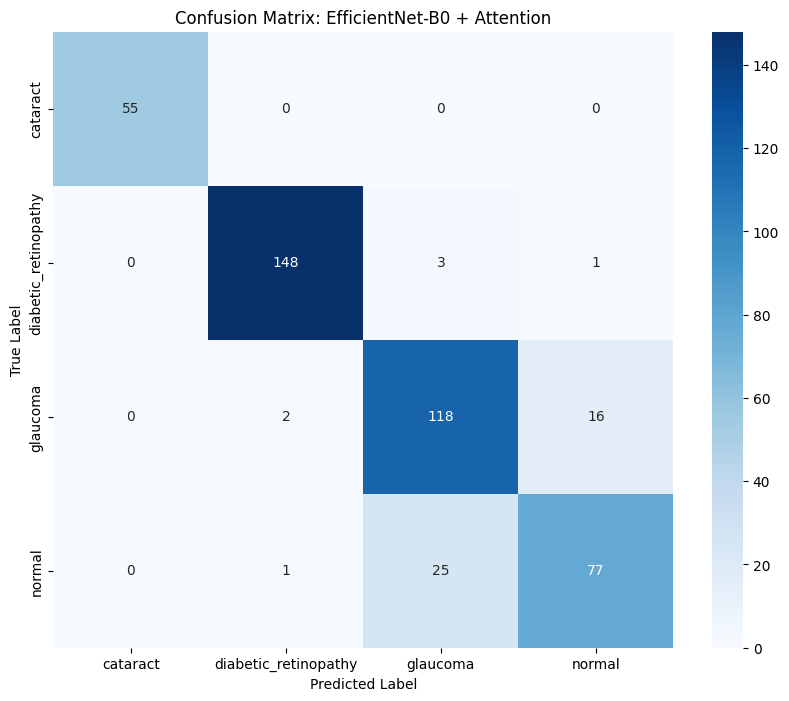

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# 1. Re-initialize the Model Structure
test_model = timm.create_model('efficientnet_b0', pretrained=False, num_classes=0)
test_model.classifier = AttentionHead(test_model.num_features, 4)

# 2. Load the Saved Weights
test_model.load_state_dict(torch.load(SAVE_PATH))
test_model.to(DEVICE)
test_model.eval()

# 3. Prepare the Test Loader
test_ds = datasets.ImageFolder(f"{DATA_PATH}/test", transform=val_transforms)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

# 4. Perform Inference
y_true = []
y_pred = []

print("Running final evaluation on Test Set...")
with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images = images.to(DEVICE)
        outputs = test_model(images)
        preds = torch.argmax(outputs, dim=1)
        
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

# 5. Display Metrics
classes = test_ds.classes

print("\n" + "="*30)
print("       FINAL TEST METRICS")
print("="*30)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=classes))

# 6. Plot Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix: EfficientNet-B0 + Attention')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import timm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
from tqdm import tqdm

# Constants
DATA_PATH = "/kaggle/input/datasets/mahin661/eye-disease-classification-fundus-image-dataset/dataset2_balanced"
BATCH_SIZE = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# EfficientNet Transforms (Heavy Augmentation)
eff_train_trans = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Swin Transformer Transforms (RandAugment is better for ViTs)
swin_train_trans = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Validation & Test Transforms
val_trans = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Loaders
train_eff_loader = DataLoader(datasets.ImageFolder(f"{DATA_PATH}/train", transform=eff_train_trans), batch_size=BATCH_SIZE, shuffle=True)
train_swin_loader = DataLoader(datasets.ImageFolder(f"{DATA_PATH}/train", transform=swin_train_trans), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(datasets.ImageFolder(f"{DATA_PATH}/val", transform=val_trans), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(datasets.ImageFolder(f"{DATA_PATH}/test", transform=val_trans), batch_size=BATCH_SIZE, shuffle=False)

classes = datasets.ImageFolder(f"{DATA_PATH}/train").classes

In [7]:
eff_model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=4).to(DEVICE)
optimizer = optim.AdamW(eff_model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

eff_history = {'train_loss': [], 'val_loss': []}

for epoch in range(10): # Adjust epochs as needed
    eff_model.train()
    t_loss = 0
    for imgs, lbls in tqdm(train_eff_loader, desc=f"EffNet Epoch {epoch+1}"):
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(eff_model(imgs), lbls)
        loss.backward()
        optimizer.step()
        t_loss += loss.item()
    
    eff_model.eval()
    v_loss = 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            v_loss += criterion(eff_model(imgs), lbls).item()
    
    eff_history['train_loss'].append(t_loss/len(train_eff_loader))
    eff_history['val_loss'].append(v_loss/len(val_loader))
    print(f"Epoch {epoch+1}: Train Loss: {eff_history['train_loss'][-1]:.4f} | Val Loss: {eff_history['val_loss'][-1]:.4f}")

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

EffNet Epoch 1: 100%|██████████| 163/163 [00:54<00:00,  3.01it/s]


Epoch 1: Train Loss: 0.7134 | Val Loss: 0.3686


EffNet Epoch 2: 100%|██████████| 163/163 [00:42<00:00,  3.85it/s]


Epoch 2: Train Loss: 0.3462 | Val Loss: 0.2755


...

Epoch 8: Train Loss: 0.1663 | Val Loss: 0.3283


EffNet Epoch 9: 100%|██████████| 163/163 [00:44<00:00,  3.67it/s]


Epoch 9: Train Loss: 0.1478 | Val Loss: 0.3296


EffNet Epoch 10: 100%|██████████| 163/163 [00:44<00:00,  3.67it/s]


Epoch 10: Train Loss: 0.1418 | Val Loss: 0.3837


In [8]:
swin_model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=4).to(DEVICE)
optimizer = optim.AdamW(swin_model.parameters(), lr=5e-5) 

swin_history = {'train_loss': [], 'val_loss': []}

for epoch in range(10):
    swin_model.train()
    t_loss = 0
    for imgs, lbls in tqdm(train_swin_loader, desc=f"Swin Epoch {epoch+1}"):
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(swin_model(imgs), lbls)
        loss.backward()
        optimizer.step()
        t_loss += loss.item()
    
    swin_model.eval()
    v_loss = 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            v_loss += criterion(swin_model(imgs), lbls).item()
            
    swin_history['train_loss'].append(t_loss/len(train_swin_loader))
    swin_history['val_loss'].append(v_loss/len(val_loader))
    print(f"Epoch {epoch+1}: Train Loss: {swin_history['train_loss'][-1]:.4f} | Val Loss: {swin_history['val_loss'][-1]:.4f}")

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Swin Epoch 1: 100%|██████████| 163/163 [01:35<00:00,  1.71it/s]


Epoch 1: Train Loss: 0.4459 | Val Loss: 0.2803


Swin Epoch 2: 100%|██████████| 163/163 [01:33<00:00,  1.74it/s]


Epoch 2: Train Loss: 0.3014 | Val Loss: 0.2724


...

Epoch 8: Train Loss: 0.1985 | Val Loss: 0.2256


Swin Epoch 9: 100%|██████████| 163/163 [01:33<00:00,  1.75it/s]


Epoch 9: Train Loss: 0.2000 | Val Loss: 0.3337


Swin Epoch 10: 100%|██████████| 163/163 [01:33<00:00,  1.74it/s]


Epoch 10: Train Loss: 0.1809 | Val Loss: 0.2488



--- EfficientNet-B0 Classification Report ---
                      precision    recall  f1-score   support

            cataract       1.00      1.00      1.00        55
diabetic_retinopathy       0.99      0.97      0.98       152
            glaucoma       0.82      0.71      0.76       136
              normal       0.67      0.81      0.73       103

            accuracy                           0.86       446
           macro avg       0.87      0.87      0.87       446
        weighted avg       0.86      0.86      0.86       446



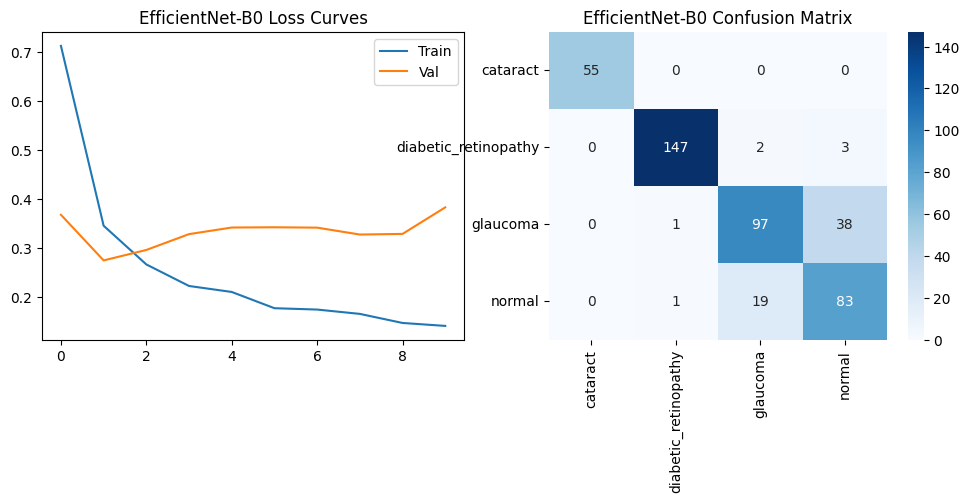


--- Swin-Transformer Classification Report ---
                      precision    recall  f1-score   support

            cataract       1.00      1.00      1.00        55
diabetic_retinopathy       0.99      0.97      0.98       152
            glaucoma       0.82      0.83      0.83       136
              normal       0.77      0.80      0.78       103

            accuracy                           0.89       446
           macro avg       0.90      0.90      0.90       446
        weighted avg       0.89      0.89      0.89       446



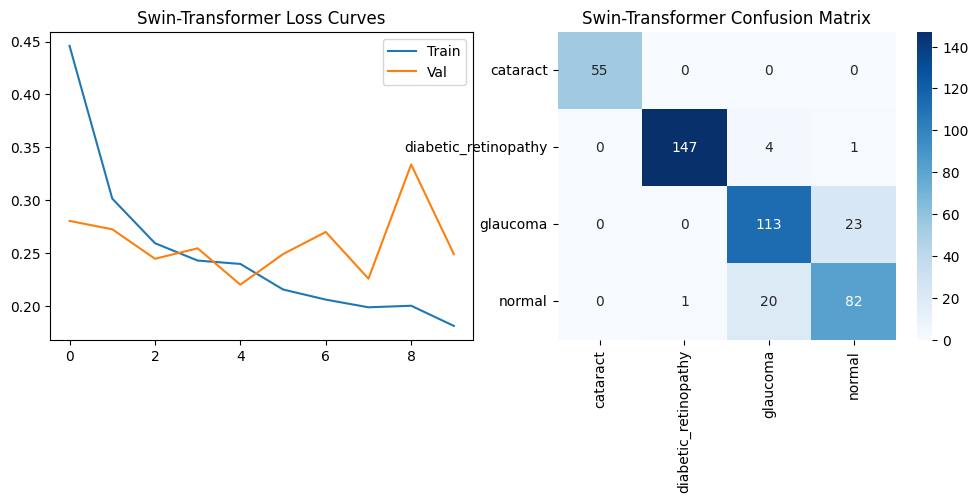

In [9]:
def plot_and_evaluate(model, history, name):
    # 1. Plot Loss
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train')
    plt.plot(history['val_loss'], label='Val')
    plt.title(f'{name} Loss Curves')
    plt.legend()

    # 2. Evaluation Metrics on Test Set
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            y_pred.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            y_true.extend(lbls.numpy())
    
    print(f"\n--- {name} Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=classes))
    
    # 3. Confusion Matrix
    plt.subplot(1, 2, 2)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(f'{name} Confusion Matrix')
    plt.show()

plot_and_evaluate(eff_model, eff_history, "EfficientNet-B0")
plot_and_evaluate(swin_model, swin_history, "Swin-Transformer")

In [10]:
import torch.nn.functional as F

def ensemble_predict(model_eff, model_swin, loader, weight_eff=0.4, weight_swin=0.6):
    model_eff.eval()
    model_swin.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(DEVICE)
            
            # Get raw outputs (logits)
            out_eff = model_eff(imgs)
            out_swin = model_swin(imgs)
            
            # Convert to probabilities using Softmax
            prob_eff = F.softmax(out_eff, dim=1)
            prob_swin = F.softmax(out_swin, dim=1)
            
            # Weighted average of probabilities
            final_probs = (prob_eff * weight_eff) + (prob_swin * weight_swin)
            
            preds = torch.argmax(final_probs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.numpy())
            
    return all_labels, all_preds

# Run the ensemble evaluation
y_true, y_pred = ensemble_predict(eff_model, swin_model, test_loader)

print("--- Ensemble Classification Report ---")
print(classification_report(y_true, y_pred, target_names=classes))

--- Ensemble Classification Report ---
                      precision    recall  f1-score   support

            cataract       1.00      1.00      1.00        55
diabetic_retinopathy       0.99      0.97      0.98       152
            glaucoma       0.83      0.80      0.81       136
              normal       0.75      0.81      0.78       103

            accuracy                           0.88       446
           macro avg       0.89      0.89      0.89       446
        weighted avg       0.89      0.88      0.88       446

